#  **Preprocessing**

In [0]:
import pandas as pd

# Import our synthetic dataset from GitHub repo
raw_url = "https://raw.githubusercontent.com/jazz1416/VetTrack-Customer-Service-Agent/refs/heads/main/synthetic_customer_support_tickets.csv"
df = pd.read_csv(raw_url)
df = df[df['Ticket Status'] == 'Closed']

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Minutes to resolve
0,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,7/14/20,Client Communication (Email/SMS),SMS Reminders Not Sending,We've noticed that SMS reminders for upcoming ...,Closed,We conducted a thorough investigation and foun...,Critical,Social media,6/1/23 11:14,6/1/23 18:05,3.0,120.0
1,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,11/13/20,Client Communication (Email/SMS),SMS Reminders Not Sending,Clients have reported that they are not receiv...,Closed,"After analyzing the system logs, we discovered...",Critical,Social media,6/1/23 7:29,6/1/23 1:57,3.0,90.0
2,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2/4/20,Client Communication (Email/SMS),SMS Reminders Not Sending,The SMS reminders for pet vaccinations are fai...,Closed,The issue was traced back to a software update...,Critical,Email,6/1/23 0:12,6/1/23 19:53,1.0,150.0
3,11,Joseph Moreno,mbrown@example.org,48,Male,Nintendo Switch,1/19/21,Client Communication (Email/SMS),SMS Reminders Not Sending,We're experiencing an issue where no SMS remin...,Closed,"Upon review, we found a server-side script fai...",Critical,Phone,6/1/23 17:46,5/31/23 23:51,1.0,110.0
4,12,Brandon Arnold,davisjohn@example.net,51,Male,Microsoft Xbox Controller,10/24/21,Client Communication (Email/SMS),SMS Reminders Not Sending,All SMS reminders for our upcoming appointment...,Closed,The SMS queue was overloaded due to a bug in t...,Critical,Chat,6/1/23 12:05,6/1/23 9:27,1.0,130.0


In [0]:
# Get columns that contain n/a values
df.columns[df.isna().any()].tolist()

[]

In [0]:
import pandas as pd

# Cast columns to proper data types
df['Ticket ID'] = df['Ticket ID'].astype('int64')
df['Customer Name'] = df['Customer Name'].astype('string')
df['Customer Email'] = df['Customer Email'].astype('string')
df['Customer Age'] = df['Customer Age'].astype('int64')
df['Customer Gender'] = df['Customer Gender'].astype('string')
df['Product Purchased'] = df['Product Purchased'].astype('string')
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'], format='%m/%d/%y')
df['Ticket Type'] = df['Ticket Type'].astype('string')
df['Ticket Subject'] = df['Ticket Subject'].astype('string')
df['Ticket Description'] = df['Ticket Description'].astype('string')
df['Ticket Status'] = df['Ticket Status'].astype('string')
df['Resolution'] = df['Resolution'].astype('string')
df['Ticket Priority'] = df['Ticket Priority'].astype('string')
df['Ticket Channel'] = df['Ticket Channel'].astype('string')
df['First Response Time'] = pd.to_datetime(df['First Response Time'], format='%m/%d/%y %H:%M')
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'], format='%m/%d/%y %H:%M')
df['Customer Satisfaction Rating'] = df['Customer Satisfaction Rating'].astype('int64')
df['Minutes to resolve'] = df['Minutes to resolve'].astype('Int64')

In [0]:
import re

# Text normalization 
def normalize_text(text):
    text = str(text).lower() # str() prevents errors on nulls
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df['Ticket Description'] = df['Ticket Description'].apply(normalize_text)
df['Resolution'] = df['Resolution'].apply(normalize_text)

print(f"Filtered down to {len(df)} closed tickets for training.")

Filtered down to 2769 closed tickets for training.


In [0]:
# Columns that should be categorized
cat_cols = ['Ticket Type', 'Ticket Subject', 'Ticket Status', 'Ticket Priority']

# Create a new column with int values for each category 
for col in cat_cols:
    numerical_values, _ = pd.factorize(df[col])
    current_index = df.columns.get_loc(col)
    new_col_name = f'{col}_id'
    df.insert(current_index + 1, column = new_col_name, value = numerical_values)

In [0]:
pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.9/588.9 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.4/426.4 MB 127.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.6/444.6 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.1/221.1 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.5/188.5 MB 93.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [0]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')

# Map to the new description column
texts = df['Ticket Description'].tolist()

batch_size = 1000
embeddings = model.encode(texts, batch_size=batch_size, show_progress_bar=True)

df['embeddings'] = list(embeddings)
print(f"Created embeddings with shape: {embeddings.shape}")

/local_disk0/.ephemeral_nfs/envs/pythonEnv-b3170c8a-d7ff-405a-852f-a3e4a2a70eef/lib/python3.12/site-packages/torch/_vmap_internals.py:9: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  from torch.utils._pytree import _broadcast_to_and_flatten, tree_flatten, tree_unflatten


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Created embeddings with shape: (2769, 384)


In [0]:
# Create the default catalog and schema if they don't already exist
spark.sql("CREATE CATALOG IF NOT EXISTS main")
spark.sql("CREATE SCHEMA IF NOT EXISTS main.default")

DataFrame[]

In [0]:
# Unity Catalog location: catalog.schema.table
catalog = "main"
schema = "default"
table_name = "final_project_data"

# Rename columns to replace spaces with underscores 
df.columns = df.columns.str.replace(' ', '_')

# Convert Pandas DataFrame to Spark and write as Delta
# mode("overwrite") replaces the table if it exists (good for re-running the lab)
final_project_data = spark.createDataFrame(df)
final_project_data.write.format("delta").mode("overwrite").saveAsTable(f"{catalog}.{schema}.{table_name}")

# Verify: query the table
display(spark.table(f"{catalog}.{schema}.{table_name}").limit(5))

Ticket_ID Customer_Name Customer_Email Customer_Age Customer_Gender Product_Purchased Date_of_Purchase Ticket_Type Ticket_Type_id Ticket_Subject Ticket_Subject_id Ticket_Description Ticket_Status Ticket_Status_id Resolution Ticket_Priority Ticket_Priority_id Ticket_Channel First_Response_Time Time_to_Resolution Customer_Satisfaction_Rating Minutes_to_resolve embeddings 3 Christopher Robbins gonzalestracy@example.com 48 Other Dell XPS 2020-07-14T00:00:00.000Z Client Communication (Email/SMS) 0 SMS Reminders Not Sending 0 weve noticed that sms reminders for upcoming appointments are not being sent out this is causing confusion among clients leading to missed appointments please investigate the issue as soon as possible Closed 0 we conducted a thorough investigation and found that the sms gateway integration was misconfigured the settings have been corrected and sms reminders have been successfully tested all pending reminders have been queued for delivery Critical 0 Social media 2023-06-01T11:14:00.000Z 2023-06-01T18:05:00.000Z 3 120 List(-0.037921533, -0.02217129, 0.04189768, 0.0115335435, -0.027239922, 0.017006394, 0.0047783433, -0.010997297, 0.06396476, -0.009996365, -0.0014278959, 0.027684072, 0.01259976, 0.031078361, 0.047705546, -0.030010717, 0.026009174, -0.14006132, -0.03084088, 0.051459122, -0.02753554, 0.0429774, 0.0037636475, 0.0715892, 0.0030942312, -0.034971904, -0.052736446, -0.03390209, 0.012167375, 0.08758279, 0.0077896, 0.0765394, -0.037585188, -0.00933181, 0.018244429, 0.018066041, -0.043831415, 0.047835942, -0.008674776, 0.042116627, -0.057525884, -0.02792561, -0.0072944406, 0.012570729, 0.058726765, -0.06116939, -0.011988359, -0.013769933, -0.05808614, 0.022702012, -6.365173E-5, -0.110380895, -0.022277026, 0.054907303, -0.045609307, 0.075857736, 0.018238073, 0.05267814, 0.047409154, 0.022080895, -0.062262665, -0.027277004, -0.052507374, -0.016536623, -0.08409431, 0.058951486, -0.07526562, -0.024028488, 0.083539166, -0.019785522, 0.025503235, 0.010124289, -0.014392236, 0.07794367, 0.013033137, 0.0716955, 0.016237982, 0.0068998104, 0.0022223901, 0.013078383, -0.110806614, -0.059767142, 0.0388166, -0.031741545, 0.047695734, -0.0049347933, -0.012742999, 0.046635844, -0.074806586, -0.064337015, 0.09352512, 0.05152733, -0.041428283, 0.014485438, -0.09378259, 0.059134346, -0.056345124, 0.08355101, -0.043776322, 0.01660881, 0.03527399, 0.06432912, -0.05173675, 0.13517928, -0.057433076, 0.014451603, -0.021460231, -0.08789703, -0.025586983, -0.0028198466, -0.03701033, -0.031132882, 0.103048995, -0.02256764, -0.121052, -0.0034888329, 0.028164605, 0.064155094, 0.032314923, 0.08236423, -0.078486145, 0.038103547, -0.011673425, -0.06990782, 0.012471993, 0.029797431, 0.09163673, 2.8043842E-33, -0.08067861, 0.024113327, 0.011685999, -0.038922828, 0.032186553, -0.07382974, -0.015383944, -0.06431803, 0.091992095, -0.11870404, -0.043690775, 0.002985913, 0.074916214, -0.046436854, -0.086584225, -0.0020033836, 0.06521131, 0.11302735, 0.052285317, 0.0113546625, -0.071581915, -0.031979386, -0.0044254283, -0.011472202, -0.019899497, 0.08513587, 0.08175246, 0.06426235, 0.09804201, -0.0028253766, 0.006858037, 0.024719922, 0.10344345, 0.047819186, 0.016530786, 0.016149342, 0.022400415, -0.031507105, 0.01707302, -0.065734476, -0.0439448, -0.003423635, -0.018088007, -0.06924114, -0.050484497, -0.0018068447, 0.06199504, -0.034492582, 0.0681839, 0.048032645, 5.02262E-4, -0.0073375856, -0.012653827, 0.065960824, -0.022596303, -0.048119064, 0.080729626, -0.089032345, -0.021863725, -0.026513154, 0.039217364, -0.041297574, 0.022038918, -0.04536791, -0.011525561, -0.11414539, -0.039138317, -0.03380412, 0.02115672, -0.01305822, 0.027226007, 0.113491885, 0.10227765, 0.04211631, -0.029204946, 0.033955514, -0.0010579304, -0.039253045, 0.016469995, 0.050377574, -0.008042615, 0.030388605, 0.080129005, -0.021747524, -0.007922426, 0.019010512, -0.010334585, -0.02262286, -0.0157653, 0.1446414, -0.0853759, 0.0067393375, -0.040012985, 0.09620684, 0.0436990

# Exploratory Data **Analysis**

### Dataset Overview

In [0]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 2769
Columns: 23


In [0]:
#column types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2769 entries, 0 to 2768
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Ticket_ID                     2769 non-null   int64         
 1   Customer_Name                 2769 non-null   string        
 2   Customer_Email                2769 non-null   string        
 3   Customer_Age                  2769 non-null   int64         
 4   Customer_Gender               2769 non-null   string        
 5   Product_Purchased             2769 non-null   string        
 6   Date_of_Purchase              2769 non-null   datetime64[ns]
 7   Ticket_Type                   2769 non-null   string        
 8   Ticket_Type_id                2769 non-null   int64         
 9   Ticket_Subject                2769 non-null   string        
 10  Ticket_Subject_id             2769 non-null   int64         
 11  Ticket_Description            

In [0]:
#summary stats
df.describe()

,Ticket_ID,Customer_Age,Date_of_Purchase,Ticket_Type_id,Ticket_Subject_id,Ticket_Status_id,Ticket_Priority_id,First_Response_Time,Time_to_Resolution,Customer_Satisfaction_Rating,Minutes_to_resolve
count,2769.000000,2769.000000,2769,2769.000000,2769.000000,2769.0,2769.000000,2769,2769,2769.000000,2769.0
mean,4237.163597,44.333694,2020-12-28 16:55:38.678223104,2.564103,10.350307,0.0,1.525099,2023-06-01 11:20:19.458288128,2023-06-01 11:16:51.722643456,2.991333,59.970386
min,3.000000,18.000000,2020-01-01 00:00:00,0.000000,0.000000,0.0,0.000000,2023-05-31 21:55:00,2023-05-31 21:53:00,1.000000,5.0
25%,2145.000000,31.000000,2020-06-29 00:00:00,1.000000,4.000000,0.0,1.000000,2023-06-01 05:19:00,2023-06-01 05:34:00,2.000000,12.0
50%,4240.000000,45.000000,2020-12-26 00:00:00,2.000000,10.000000,0.0,2.000000,2023-06-01 11:22:00,2023-06-01 11:17:00,3.000000,30.0
75%,6329.000000,57.000000,2021-07-01 00:00:00,4.000000,16.000000,0.0,2.000000,2023-06-01 17:27:00,2023-06-01 17:07:00,4.000000,110.0
max,8468.000000,70.000000,2021-12-30 00:00:00,6.000000,23.000000,0.0,3.000000,2023-06-02 00:54:00,2023-06-02 00:55:00,5.000000,480.0
std,2446.830952,15.195495,NaN,1.697379,6.637447,0.0,1.068889,NaN,NaN,1.407016,59.790408


### Feature Analysis

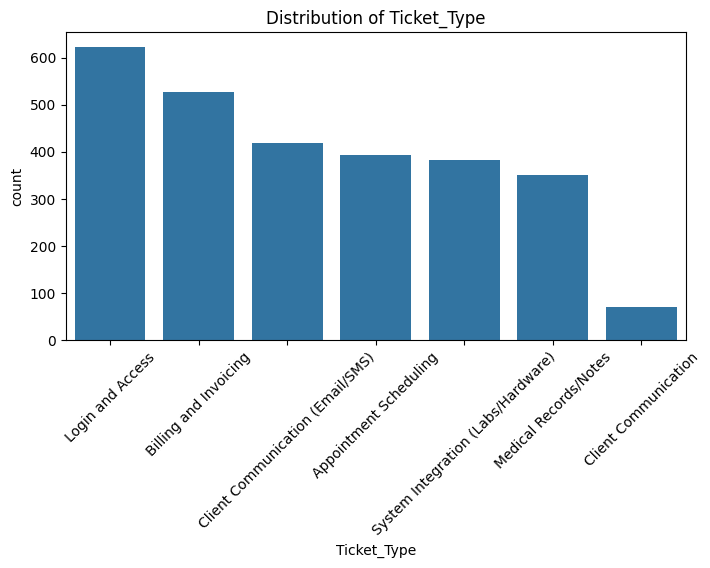

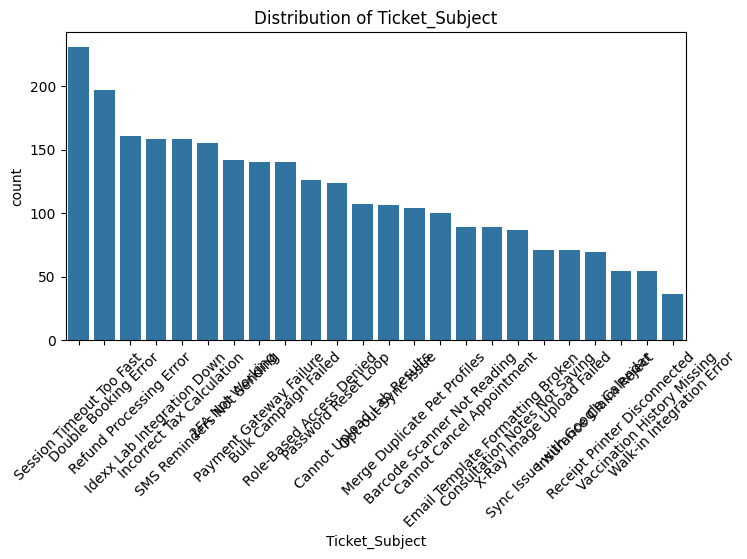

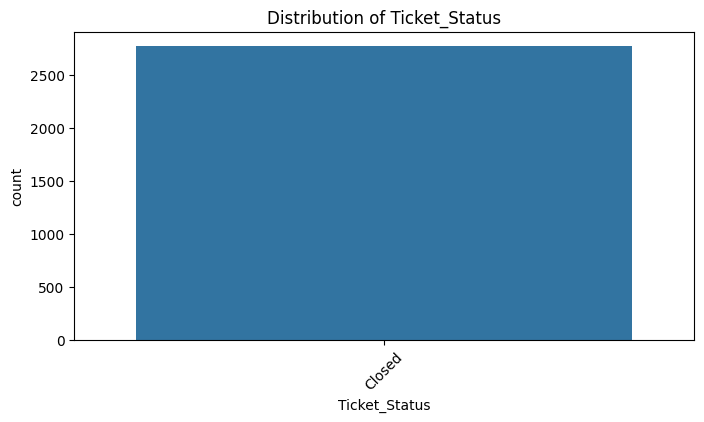

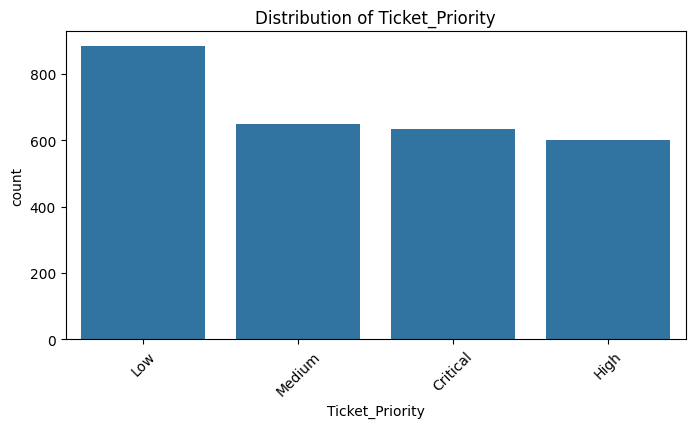

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['Ticket_Type', 'Ticket_Subject', 'Ticket_Status', 'Ticket_Priority']

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()


### Text analysis

In [0]:
%pip install nltk

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/spark-b3170c8a-d7ff-405a-852f-a3/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


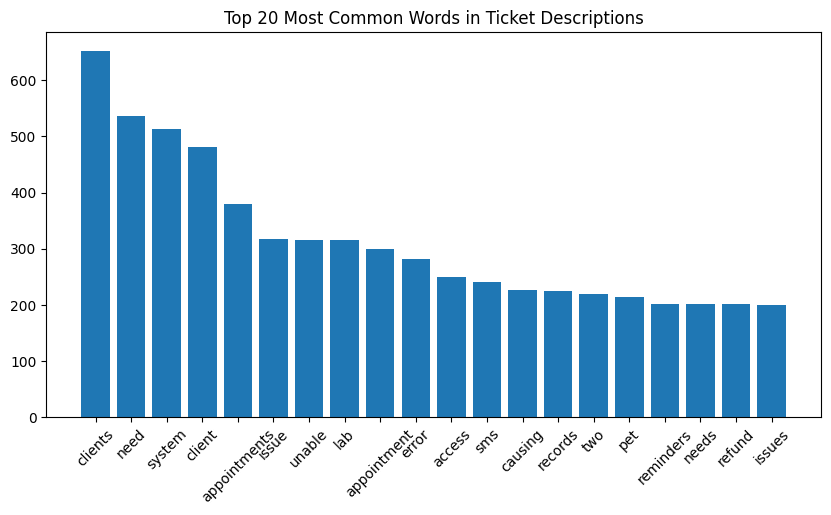

In [0]:
from collections import Counter
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Combine all issue descriptions
all_text = " ".join(df['Ticket_Description'])

# Tokenize
words = [w for w in all_text.split() if w not in stop_words]

# Most common words
word_freq = Counter(words).most_common(20)

word_df = pd.DataFrame(word_freq, columns=['word', 'count'])
plt.figure(figsize=(10,5))
plt.bar(word_df['word'], word_df['count'])
plt.xticks(rotation=45)
plt.title("Top 20 Most Common Words in Ticket Descriptions")
plt.show()

### Embedding

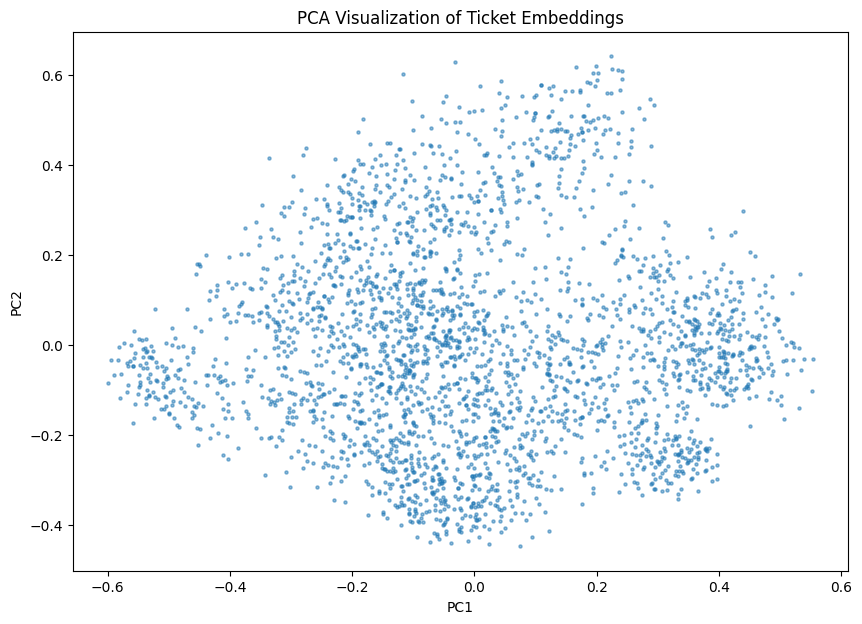

In [0]:
from sklearn.decomposition import PCA

# Convert embeddings column to array
emb_matrix = np.vstack(df['embeddings'].values)

# Reduce to 2D
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(emb_matrix)

# Plot
plt.figure(figsize=(10,7))
plt.scatter(emb_2d[:,0], emb_2d[:,1], s=5, alpha=0.5)
plt.title("PCA Visualization of Ticket Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


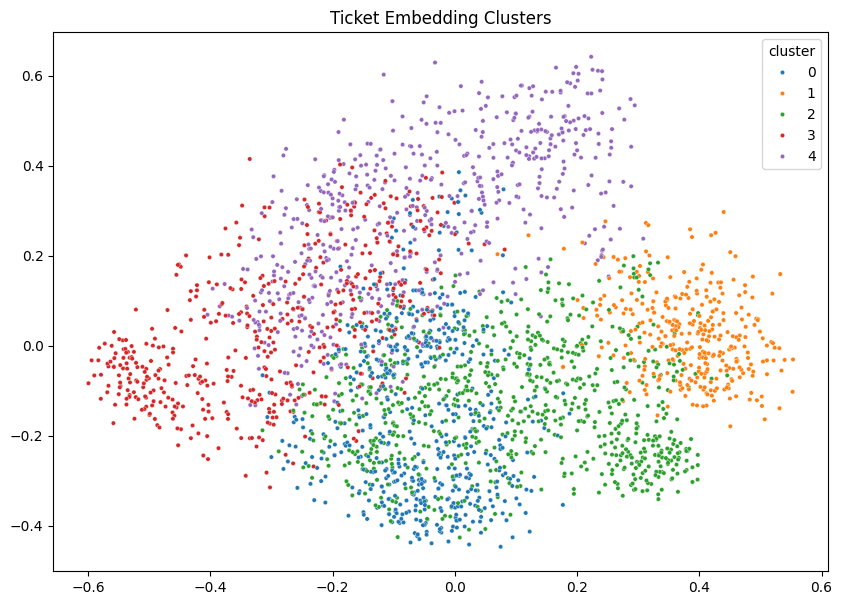


Cluster 0 top words:
[('the', 552), ('a', 510), ('to', 488), ('for', 313), ('is', 297), ('this', 282), ('our', 236), ('client', 220), ('we', 214), ('refund', 199), ('tax', 193), ('clients', 188), ('are', 170), ('an', 167), ('system', 153), ('i', 143), ('payment', 127), ('their', 121), ('and', 115), ('error', 112)]

Cluster 1 top words:
[('the', 379), ('lab', 309), ('to', 306), ('is', 223), ('results', 196), ('upload', 181), ('idexx', 159), ('for', 156), ('we', 140), ('this', 137), ('i', 133), ('our', 131), ('integration', 117), ('a', 106), ('are', 97), ('and', 90), ('not', 89), ('system', 86), ('unable', 80), ('error', 74)]

Cluster 2 top words:
[('the', 905), ('to', 795), ('i', 567), ('is', 495), ('my', 410), ('this', 320), ('a', 255), ('our', 243), ('in', 235), ('access', 197), ('for', 189), ('and', 183), ('not', 183), ('reset', 170), ('are', 169), ('system', 169), ('password', 165), ('session', 151), ('it', 141), ('am', 137)]

Cluster 3 top words:
[('to', 377), ('our', 377), ('this

In [0]:
from sklearn.cluster import KMeans

pca = PCA(n_components=10).fit_transform(emb_matrix)

# Cluster embeddings
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(pca)

# Visualize clusters
plt.figure(figsize=(10,7))
sns.scatterplot(x=pca[:,0], y=pca[:,1], hue=df['cluster'], palette='tab10', s=10)
plt.title("Ticket Embedding Clusters")
plt.show()

def top_words_for_cluster(cluster_id, n=20):
    texts = df[df['cluster'] == cluster_id]['Ticket_Description']
    all_words = " ".join(texts).split()
    common = Counter(all_words).most_common(n)
    return common

for c in sorted(df['cluster'].unique()):
    print(f"\nCluster {c} top words:")
    print(top_words_for_cluster(c))

def sample_tickets(cluster_id, n=5):
    return df[df['cluster'] == cluster_id]['Ticket_Description'].head(n)

for c in sorted(df['cluster'].unique()):
    print(f"\nCluster {c} sample tickets:")
    print(sample_tickets(c))

In [0]:
# 1. Calculate High Priority Rate
cluster_high_priority = (
    df.groupby('cluster')
      .apply(lambda x: (x['Ticket_Priority'].isin(['High', 'Critical'])).mean(), include_groups=False)
      .sort_values()
)
print("High Priority Rate by Cluster:")
print(cluster_high_priority)

# 2. Utilize the new Minutes to resolve column!
cluster_resolution = df.groupby('cluster')['Minutes_to_resolve'].mean().sort_values()
print("\nMean Minutes to Resolve by Cluster:")
print(cluster_resolution)

High Priority Rate by Cluster:
cluster
1    0.322674
2    0.370417
4    0.460133
0    0.509946
3    0.569937
dtype: float64

Mean Minutes to Resolve by Cluster:
cluster
1    42.136628
0    54.625678
4    60.262458
3    65.473904
2    67.907712
Name: Minutes_to_resolve, dtype: Float64
